# +1, +2 Nucleosome Occupancy Clustering

9/10/24 - Notebook to check if there is something interesting about the pattern of cycling occupancy between the +1, +2 nucleosomes. Upon clustering the occupancy counts for this region, nothing appears to show up in Gene Ontology. Further study would be required. But currently, there isn't much of a reason to pursue this line of study.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from src.gene_clustering import GeneClustering

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'

gene_clustering = GeneClustering(outdir)

# Analysis of Inter +1, +2 occupancy

Is there something to note about genes with cycling occupancy in the region between the +1 +2?

Text(0.5, 1.0, '+1, +2 nucleosome region')

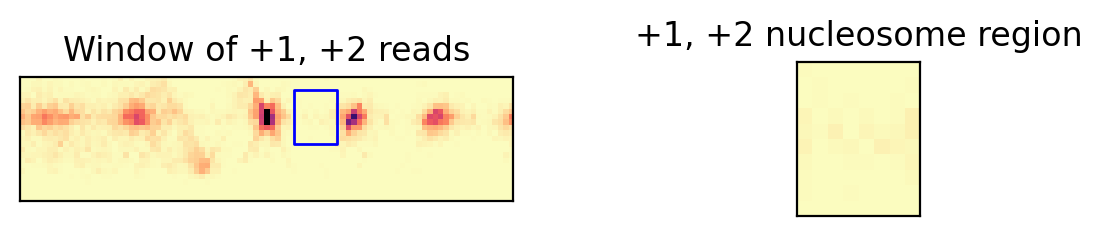

In [626]:
from src.plot_helpers import plot_rect2

cur_cluster_chrom = gene_clustering.current_cluster_chromatin
cur_chromatin_mean = gene_clustering.current_cluster_chromatin.mean(axis=0)

x1, x2 = 50, 58
y1, y2 = 10, 20
plt_idx = 10

plt.figure(figsize=(7, 1))
plt.subplot(1, 2, 1)
plt.imshow(cur_chromatin_mean[plt_idx], origin='lower', cmap='magma_r', vmax=10)
plt.xticks([])
plt.yticks([])
ax = plt.gca()
plot_rect2(ax, x1, y1, x2, y2, edgecolor='blue', fill=None, 
    lw=1, zorder=100)
plt.title("Window of +1, +2 reads")

plt.subplot(1, 2, 2)
selected_region = cur_chromatin_mean[:, y1:y2, x1:x2]
plt.imshow(selected_region[plt_idx], origin='lower', cmap='magma_r', vmax=10)
plt.xticks([])
plt.yticks([])
plt.title("+1, +2 nucleosome region")


Text(0, 0.5, 'Genes')

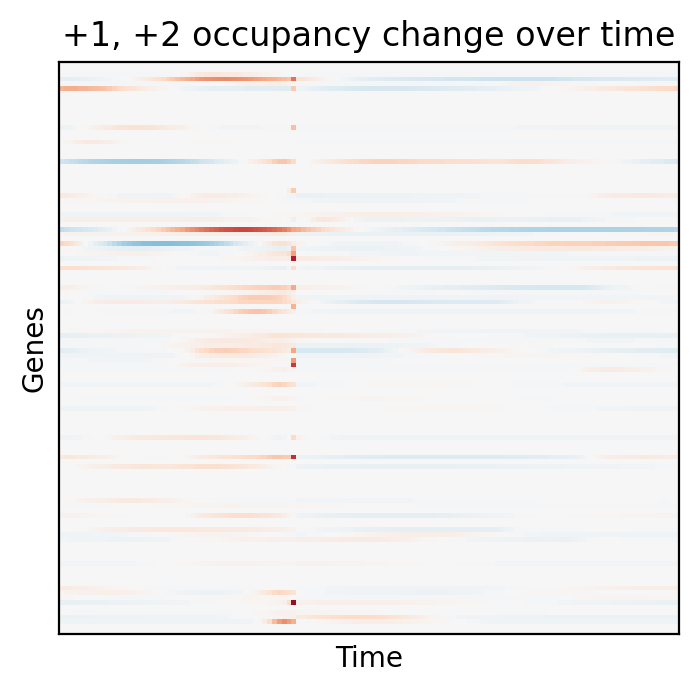

In [632]:
p1p2_nuc_reads = cur_cluster_chrom[:, :, y1:y2, x1:x2].mean(axis=2).mean(axis=2)
normed_p1p2 = (p1p2_nuc_reads - p1p2_nuc_reads.mean(axis=1).reshape((-1, 1)))
plt.figure(figsize=(4, 6))
plt.imshow(normed_p1p2, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("+1, +2 occupancy change over time")
plt.yticks([])
plt.xticks([])
plt.xlabel("Time")
plt.ylabel("Genes")

In [656]:
def get_p1p2_counts(start_i, end_i, genes):
    """Get the occupancy for the +1, +2 region of a gene"""
    cur_genes = genes.iloc[start_i:end_i]
    cur_f = load_f_files(chromatin_dir, geneset=cur_genes, log=False)
    cur_f_imgs = cur_f.values.reshape(fixed_img_shape).astype(float)[:, t_indices]
    selected_p1p2_counts = cur_f_imgs[:, :, y1:y2, x1:x2].mean(axis=2).mean(axis=2)
    return selected_p1p2_counts

In [657]:
from src.deconv_data import load_f_files
from src.timer import Timer

timer = Timer()

fixed_img_shape = (-1, 178, 23, 91)
t_indices = config.get_Hpositions_for_branch('t')
genes = gene_clustering.geneset
n = len(genes)
m = len(t_indices)

batch_size = 500
genes_p1_p2_occupancy = np.zeros((n, m))
for i in range(0, len(genes), batch_size):
    start_i, end_i = i, i+batch_size
    selected_p1p2_counts = get_p1p2_counts(start_i, end_i, genes)
    genes_p1_p2_occupancy[start_i:end_i] = selected_p1p2_counts
    timer.print_time(f"{i}/{n}")

start_i, end_i = end_i, n
selected_p1p2_counts = get_p1p2_counts(start_i, end_i, genes)
genes_p1_p2_occupancy[start_i:end_i] = selected_p1p2_counts


0/5578 - 00:00:47.005
500/5578 - 00:01:31.866
1000/5578 - 00:02:16.989
1500/5578 - 00:03:01.823
2000/5578 - 00:03:46.024
2500/5578 - 00:04:31.177
3000/5578 - 00:05:17.726
3500/5578 - 00:06:05.804
4000/5578 - 00:06:52.456
4500/5578 - 00:07:41.084
5000/5578 - 00:08:26.983
5500/5578 - 00:08:39.512


In [716]:
from src.peak_to_trough import compute_quantile_ptr_2d

p1p2_ptr = compute_quantile_ptr_2d(genes_p1p2_df, lo=0.1, hi=0.9)
p1p2_ptr_df = pd.DataFrame(p1p2_ptr, columns=['ptr'], index=genes_p1p2_df.index)

In [951]:
p1p2_ptr_df['q10'] = genes_p1p2_df.quantile(0.1, axis=1)
p1p2_ptr_df['q90'] = genes_p1p2_df.quantile(0.9, axis=1)
p1p2_ptr_df

,ptr,q10,q90
orf_name,,,
YAL067W-A,1.000000,0.000010,0.000010
YAL067C,1.556492,0.527214,1.383013
YAL064C-A,1.000000,0.000010,0.000010
YAL064W,1.109626,0.019548,0.131699
YAL063C-A,1.000000,0.000010,0.000010
...,...,...,...
YPR198W,1.133287,0.022525,0.159853
YPR199C,1.349662,0.014244,0.369168
YPR200C,1.131607,0.000322,0.134255


558 1.2186362494762046
308 1.2186362494762046


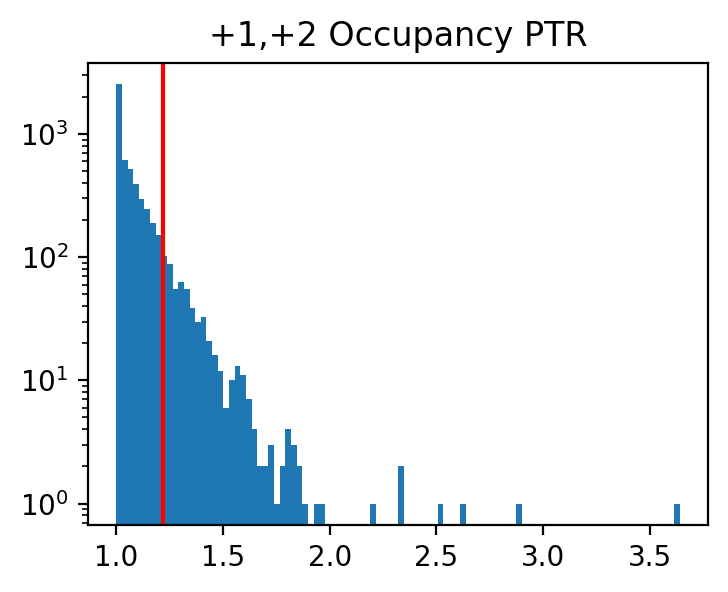

In [983]:
plt.figure(figsize=(4, 3))
plt.hist(p1p2_ptr, bins=100)
plt.yscale('log')

q_ptr = 0.9

q_val = np.quantile(p1p2_ptr_df.ptr, q_ptr)
quantile_ptr_genes = p1p2_ptr_df[p1p2_ptr_df.ptr > q_val]
plt.axvline(q_val, c='red')
plt.title("+1,+2 Occupancy PTR")

print(len(quantile_ptr_genes), q_val)

selected_p1p2 = p1p2_ptr_df.loc[quantile_ptr_genes.index].sort_values('q90')
selected_p1p2 = p1p2_ptr_df[p1p2_ptr_df.q90 > 0.5]

hi_ptr_p1p2_occ = genes_p1p2_df.loc[selected_p1p2.index]

print(len(selected_p1p2), q_val)


In [998]:
from src.gene_clustering import circular_distance

# Unnormalized hi PTR p1 p2 occupancy values
time_series_data = hi_ptr_p1p2_occ.values

n_samples = len(time_series_data)
distance_matrix = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    for j in range(i + 1, n_samples):
        distance = circular_distance(time_series_data[i], time_series_data[j])
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance

    if i % 100 == 0:
        timer.print_time(f"{i}/{n_samples}")

# Handle close to zero values that are negative
distance_matrix[distance_matrix < 0] = 0
timer.print_time()

0/308 - 02:49:33.047
100/308 - 02:49:33.899
200/308 - 02:49:34.408
300/308 - 02:49:34.591
02:49:34.592


In [999]:
from src.gene_clustering import cluster_timeseries_kmedoids

num_clusters = 11
kmedoids, labels, medoid_indices = cluster_timeseries_kmedoids(distance_matrix, num_clusters)
labels = labels+1

In [1000]:
cluster_idx_df = pd.DataFrame(
    {'gene_index': np.arange(distance_matrix.shape[0]),
     'cluster': labels}, index=hi_ptr_p1p2_occ.index)
cluster_idx_df = cluster_idx_df.reset_index().set_index(['cluster', 'orf_name'])
cluster_idx_df = cluster_idx_df.sort_index()

([], [])

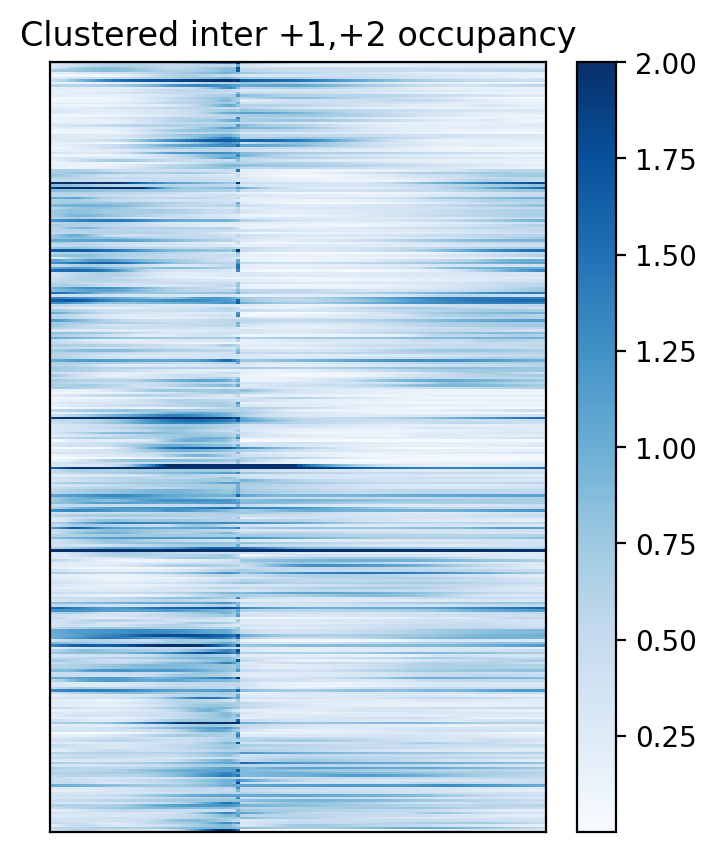

In [1001]:
plt.figure(figsize=(4, 5))

plt.imshow(hi_ptr_p1p2_occ.loc[cluster_idx_df.reset_index()['orf_name']], 
           vmax=2, aspect='auto', cmap='Blues', interpolation='none')
plt.title("Clustered inter +1,+2 occupancy")
plt.colorbar()
plt.yticks([])
plt.xticks([])


In [1002]:
from src.gene_clustering import run_gene_ontology_on_clustered_genes
all_results, all_sigfig = run_gene_ontology_on_clustered_genes(gene_clustering.geneset,
                                    cluster_idx_df)
all_sigfig

data/go.obo: fmt(1.2) rel(2018-08-29) 47,313 Terms


,id,name,pop_count,pop_n,study_count,study_n,pop_items,study_items,fdr_bh,bonferroni,cluster
